# HW_NLP_01_MohsenMohebbi

---
This exercise consists of four main sections and includes four primary tasks:

1. **Data Extraction (Web Scraping):**  
   Use Selenium and BeautifulSoup to extract data from the Jobinja website:  
   https://jobinja.ir/

2. **Data Cleaning:**  
   Clean a new dataset using regular expressions (`regex`) and (`hazm`):  
   https://www.kaggle.com/datasets/amirpourmand/asriran-news

3. **Content-Based Search Engine:**  
   Build a search engine using **TF-IDF** and **Cosine Similarity**.

4. **Multiclass News Topic Classification:**  
   Classify news articles into multiple topic categories.


## Task 1: **Data Extraction with Selenium and BeautifulSoup**  
   **Goal:** Learn how to scrape data from websites with multiple pages (pagination) and extract structured data.

### Workflow Steps

1. **Setup:**
   - Use Selenium to open the search results page for "Data Scientist" or "Python Developer".    


2. **Page Navigation:**
   - Write a loop to extract data from the current page, then use Selenium to click the "Next" button. Perform this for at least 3 result pages.

3. **Extraction:**
   - Use BeautifulSoup to parse the HTML of each page and extract the following information for each job listing:
     - Job Title
     - Company Name
     - Location (City)

4. **Output:**
   - Store the extracted data in a Pandas DataFrame and export it as a CSV file.


In [1]:
!pip install selenium

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 2.2 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.9 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.6 MB 3.5 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.6 MB 4.0 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 4.2 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 4.4 MB/s eta 0:00:01
   -------------------------- ------------- 6.3/9.6 MB 4.4 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.6 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 4.3 MB/s eta 0:00:01
   -------------------------------------

In [2]:
!pip install beautifulsoup4


   -------------------- ------------------- 1/2 [beautifulsoup4]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   -------------------- ------------------- 1/2 [beautifulsoup4]
   ---------------------------------------- 2/2 [beautifulsoup4]



In [3]:
!pip install chromedriver-py

   ---------------------------------------- 0.0/56.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.0 MB ? eta -:--:--
    --------------------------------------- 0.8/56.0 MB 2.1 MB/s eta 0:00:27
   - -------------------------------------- 1.8/56.0 MB 3.1 MB/s eta 0:00:18
   - -------------------------------------- 2.4/56.0 MB 3.2 MB/s eta 0:00:17
   -- ------------------------------------- 3.1/56.0 MB 3.0 MB/s eta 0:00:18
   -- ------------------------------------- 3.4/56.0 MB 2.8 MB/s eta 0:00:19
   --- ------------------------------------ 4.5/56.0 MB 3.0 MB/s eta 0:00:18
   --- ------------------------------------ 4.7/56.0 MB 2.9 MB/s eta 0:00:18
   --- ------------------------------------ 5.5/56.0 MB 3.0 MB/s eta 0:00:17
   ---- ----------------------------------- 6.8/56.0 MB 3.3 MB/s eta 0:00:16
   ----- ------------------

In [ ]:
# Packages

import json
import time
import numpy as np
import pandas as pd
from typing import Dict, List
#---------------------------------------
# Generating Random Time Intervals
import random
#---------------------------------------
# Creating Simple Classes for Storing Settings
from dataclasses import dataclass
#---------------------------------------
# Browser Creation and Control with Selenium
from selenium import webdriver
#---------------------------------------
# Chrome Settings:
# Run the browser in headless mode
# Disable notifications
# Set the browser language
from selenium.webdriver.chrome.options import Options
#---------------------------------------
# Specifying the ChromeDriver Path in Selenium
from selenium.webdriver.chrome.service import Service
#---------------------------------------
# Selecting a Method for Locating Web Elements
from selenium.webdriver.common.by import By
#---------------------------------------
# Simulate keyboard keys such as Enter, Tab, and Escape
from selenium.webdriver.common.keys import Keys
#---------------------------------------
# Element Readiness Conditions
from selenium.webdriver.support import expected_conditions as EC
#---------------------------------------
# Waiting for a Specific Condition on the Page
from selenium.webdriver.support.ui import WebDriverWait
#---------------------------------------
# Analyzing and Extracting Information from Retrieved HTML
from bs4 import BeautifulSoup
#---------------------------------------
# install googledrive
from chromedriver_py import binary_path


In [6]:
print("Path of choromdriver")
print(binary_path)

Path of choromdriver
c:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\.venv_py3_12_10\Lib\site-packages\chromedriver_py\chromedriver_win64.exe


In [ ]:
def open_jobinja_search(keyword):
    options = Options()
    options.add_argument("--start-maximized")
    options.add_argument("--disable-notifications")
    options.add_argument("--lang=fa")

    service = Service(binary_path)
    driver = webdriver.Chrome(service=service, options=options)

    driver.get("https://jobinja.ir/")

    # Wait for Popup
    wait = WebDriverWait(driver, 30)
    # Close popup
    close_popup = wait.until(
        EC.element_to_be_clickable(
            (
                By.XPATH,
                "//a[contains(@href, "user-redirect") "
                "and contains(@href, "commands") "
                "and contains(normalize-space(.), "نمی‌خواهم")]"
            )
        )
    )

    close_popup.click()

    wait.until(EC.invisibility_of_element(close_popup))

    # Find serche window
    search_box = wait.until(
        EC.element_to_be_clickable(
            (By.XPATH,
             "//input[contains(@placeholder, "عنوان شغلی، نام شرکت، مهارت")]")
        )
    )

    search_box.clear()
    search_box.send_keys(keyword)
    search_box.send_keys(Keys.ENTER)

    return driver


SEARCH_KEYWORD = "برنامه نویس پایتون"
driver = open_jobinja_search(SEARCH_KEYWORD)



all_jobs_data = []
NUM_PAGES = 3
# Change number to Farsi
fa_digits = {"1": "۱", "2": "۲", "3": "۳", "4": "۴", "5": "۵"}

for current_page in range(1, NUM_PAGES + 1):
    print(f"--- Scraping Page {current_page} ---")

    # Chcke this page, load?
    WebDriverWait(driver, 15).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "li.c-jobListView__item"))
    )

    # HTML Parser
    soup = BeautifulSoup(driver.page_source, "html.parser")
    job_cards = soup.select("li.c-jobListView__item")

    for job in job_cards:
        # Job titel
        title_tag = job.select_one("h2.c-jobListView__title a.c-jobListView__titleLink")
        title = title_tag.get_text(strip=True) if title_tag else None

        # list of Company Name, city and ...
        meta_items = job.select("ul.c-jobListView__meta li.c-jobListView__metaItem")
        
        # Company Name
        company = meta_items[0].get_text(strip=True) if len(meta_items) > 0 else ""
        
        # City
        location = meta_items[1].get_text(strip=True) if len(meta_items) > 1 else ""

        if title:
            all_jobs_data.append({
                "job_title": title,
                "company_name": company,
                "location": location,
                "page": current_page
            })

    print(f"Extracted {len(job_cards)} jobs from page {current_page}.")

    # Go to next page and scrole
    if current_page < NUM_PAGES:
        next_page_num = str(current_page + 1)
        next_page_fa = fa_digits.get(next_page_num, next_page_num)

        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(1.5)

        next_page_button = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((
                By.XPATH,
                f"//a[contains(@href, "page={next_page_num}") or normalize-space(text())="{next_page_num}" or normalize-space(text())="{next_page_fa}"]"
            ))
        )
        driver.execute_script("arguments[0].click();", next_page_button)
        time.sleep(3)

# Save ad CSV by pandas
df_jobs = pd.DataFrame(all_jobs_data)
df_jobs.to_csv("jobinja_jobs.csv", index=False, encoding="utf-8-sig")

print(f"\nCompleted! Total jobs: {len(df_jobs)}")
display(df_jobs.head(10))


--- Scraping Page 1 ---
Extracted 20 jobs from page 1.
--- Scraping Page 2 ---
Extracted 20 jobs from page 2.
--- Scraping Page 3 ---
Extracted 20 jobs from page 3.

Completed! Total jobs: 60


,job_title,company_name,location,page
0,توسعه دهنده پایتون (Python Software Engineer-A...,رهند هوشمند نوین داده | Rahand Hoshmand Novin ...,تهران، تهران,1
1,برنامه‌نویس پایتون (Python/Django-اصفهان),دانش بنیان مهندسی ارتباطی پیام پرداز | Payam P...,اصفهان، اصفهان,1
2,برنامه‌نویس Python,همیان | Hamyan,تهران، تهران,1
3,برنامه‌نویس ارشد پایتون,نت‌بان شریف | NetBaan Sharif,تهران، تهران,1
4,طراح صنعتی(فلاسک-مشهد-دورکاری),استودیو کوروش | Cyrus Studio,خراسان رضوی، مشهد,1
5,توسعه‌دهنده بک‌اند (Python-Django-کرج),میزگرد | Mizegerd,البرز، کرج,1
6,Python Developer,گروه مالی هامرز | Hummers Group,تهران، تهران,1
7,برنامه‌نویس (Python / Django),فناوری اطلاعات رسپینا رادین | Respina Radyn IT Co,تهران، تهران,1
8,برنامه‌نویس ارشد پایتون (دورکاری),پایا | RCP,تهران، تهران,1
9,توسعه‌دهنده بک‌اند (Java-Backend Developer),دانش رفاه پردیس | Danesh Refah Pardis,تهران، تهران,1


## Task 2: Data Cleaning Using `hazm` and `regex`

**Goal:** Master text normalization, noise removal, and build a preprocessing pipeline on real-world datasets.

**Task Description:** Load a DataFrame containing Persian text (e.g., Digikala reviews, SnappFood reviews, or news). You can use the dataset from Task 4. Write a function named `clean_persian_text(text)` that performs the following steps in sequence, then apply it across the entire text column using the `.apply()` method.

### Dataset
- **URL:** [Asriran News Dataset on Kaggle](https://www.kaggle.com/datasets/amirpourmand/asriran-news)


### Steps to Perform the Work:

1. **Noise Removal with Regex:**

2. **Fixing Word Elongation:**
   - Use Regex to correct words whose letters have been excessively repeated.

3. **Normalization with Hazm:**
   - Pass the text to Hazm library"s `Normalizer` to correct spacing, semi-spaces, and character unification (such as converting Arabic "ی" to Persian "ی").

4. **Stopwords Removal:**
   - Tokenize the text with Hazm. Remove standard Persian Stopwords, but be careful to exclude negation words (like "نه", "نیست", "نمی", "نبود") from the Stopwords list so they are not deleted! Otherwise, the meaning of the text will be completely lost.

5. **Final Analysis:**
   - After applying this pipeline to the entire dataframe, write code to print the top 10 most frequent words across the cleaned dataframe. (If words like "از", "به", or "که" are in this list, it means your pipeline did not work correctly).


In [1]:
import os ,math
import numpy as np
import pandas as pd
import re
from hazm import Normalizer, WordTokenizer, stopwords_list
from tqdm import tqdm
tqdm.pandas(desc="Processing")

Read data

In [2]:
df_master = pd.read_csv("asriran.csv")
df_master["body"] = df_master["body"].fillna("").astype(str)

In [45]:
df_master.head()

,title,shortlink,time,service,subgroup,abstract,body
0,پلیس: جرائم خشن و مسلحانه در تهران کاهش یافته است,https://www.asriran.com/003YoB,۰۸:۴۱ - ۲۳ تير ۱۴۰۱,صفحه نخست,عمومی,آمارهای پلیس نشان می‌دهد که جرائم خشن و مسلحان...,رئیس پلیس آگاهی تهران بزرگ اعلام کرد که موضوع ...
1,"وزیر بهداشت:\r\nآغاز اجرای طرح جامع ""دارویار""/...",https://www.asriran.com/003YoC,۰۸:۴۷ - ۲۳ تير ۱۴۰۱,صفحه نخست,اخبار سلامت,هدف اصلی وزارت بهداشت از این طرح این است که پو...,"وزیر بهداشت جزییات طرح ""دارویار"" که اجرای آن آ..."
2,وزارت بهداشت: قیمت دارو برای مصرف کننده ثابت م...,https://www.asriran.com/003YoF,۰۹:۰۸ - ۲۳ تير ۱۴۰۱,صفحه نخست,اجتماعی,NaN,سخنگوی وزارت بهداشت، درمان و آموزش پزشکی در تو...
3,معاون رئیسی: مردم به زودی شاهد اثرات مثبت اقدا...,https://www.asriran.com/003YZP,۱۶:۴۶ - ۱۶ تير ۱۴۰۱,صفحه نخست,سیاسی,معاون امور مجلس رئیس جمهور: استان گیلان دارای ...,معاون رئیس جمهور گفت: دولت برنامه های راهبردی ...
4,دستگیری سارق ۲۰ هزار دلاری ارز دیجیتال در گلستان,https://www.asriran.com/003YZN,۱۶:۴۱ - ۱۶ تير ۱۴۰۱,صفحه نخست,اجتماعی,شهروندان توصیه‌های پلیس فتا را جدی بگیرند و در...,رییس پلیس فتا فرماندهی انتظامی گلستان گفت: سار...


In [46]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 339834 entries, 0 to 339833
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   title      339834 non-null  str  
 1   shortlink  339834 non-null  str  
 2   time       339834 non-null  str  
 3   service    339834 non-null  str  
 4   subgroup   339834 non-null  str  
 5   abstract   155497 non-null  str  
 6   body       339834 non-null  str  
dtypes: str(7)
memory usage: 18.1 MB


In [3]:
print("Columns have Nan value: ")
df_master.isna().sum().loc[lambda x: x > 0]

Columns have Nan value: 


abstract    184337
dtype: int64

In [4]:
# for high speed create in out of function
CONTROL_CHARS_RE = re.compile(r"[\u200c\u200d\u200e\u200f\u202a-\u202e\ufeff\u00ad\u2060\u180e]")
RE_HTML = re.compile(r"<[^>]*>")
RE_URL = re.compile(r"https?://\S+|www\.\S+")
RE_EMAIL = re.compile(r"\S+@\S+")
RE_NON_PERSIAN = re.compile(r"[^\w\s\u0600-\u06FF]")
RE_REPEAT = re.compile(r"([^\W\d_])\1{2,}")
RE_SPACES = re.compile(r"\s+")

hazm_normalizer = Normalizer(
    correct_spacing=True, # remove spaces
    remove_diacritics=True, # remov "aarab ( ُ ِ ّ ...)"
    remove_specials_chars=False,
    decrease_repeated_chars=True, # Repeated char
    persian_style=True, # style
    persian_numbers=False
)

tokenizer = WordTokenizer(separate_emoji=False, replace_links=False, replace_ids=False)
standard_stopwords = set(stopwords_list())
negation_keep = {"نه", "نیست", "نیستند", "نیستم", "نیستیم", "نیستید", 
                  "نمی", "نمی‌شود", "نمی‌کند", "نمی‌تواند", "نبود", "نبوده", 
                  "نبودند", "نبودم", "نبودیم", "نشد", "نشده", "نشده‌اند"}

standard_stopwords = standard_stopwords - negation_keep


def clean_persian_text(text):
    if not isinstance(text, str) or not text:
        return ""
    text = CONTROL_CHARS_RE.sub(" ", text)
    text = RE_HTML.sub(" ", text)
    text = RE_URL.sub(" ", text)
    text = RE_EMAIL.sub(" ", text)
    text = RE_NON_PERSIAN.sub(" ", text)
    text = RE_REPEAT.sub(r"\1", text)
    text = RE_SPACES.sub(" ", text).strip()
    
    if not text:
        return ""

    text = hazm_normalizer.normalize(text)
    tokens = tokenizer.tokenize(text)
    return[t for t in tokens if len(t) >= 2 and t not in standard_stopwords]

# df = df_master[:1000]
# df["body_clean"] = df["body"].apply(clean_persian_text)
df_master["body_clean"] = df_master["body"].progress_apply(clean_persian_text)



Processing: 100%|██████████| 339834/339834 [07:32<00:00, 751.28it/s] 


In [ ]:
from collections import Counter

all_words = Counter(word for tokens in df_master["body_clean"] if isinstance(tokens, list) for word in tokens)

pd.DataFrame(all_words.most_common(15), columns=["Word",  "Duplicate"])



,Word,Duplicate
0,کشور,348907
1,ایران,344682
2,سال,309217
3,گزارش,253961
4,قرار,215922
5,مردم,200757
6,روز,186567
7,آمریکا,171405
8,کار,169515
9,ادامه,168838


## Task3: Movie Recommendation Model (TF-IDF and Cosine Similarity)

**Goal:** Build a simple content-based recommendation model using Vector Space Models.

**Implementation Steps:**

1. **Dataset:** Download the `TMDB 5000 Movie Dataset` from Kaggle.
   - **Important Note:** This dataset has two files. You only need to load the `tmdb_5000_movies.csv` file. For this exercise, keep only the `title` (movie name) and `overview` (plot summary) columns. (Of course, rows where `overview` is `NaN` or empty should be dropped.)

2. **Vectorization:** Convert the plot summaries into a numerical matrix using `TfidfVectorizer` (scikit-learn library). Use the `overview` column to build a stopword-removed, English-language TF-IDF matrix (`stop_words="english"`).

3. **Recommendation Model:** Write a function named `get_movie_recommendation(movie_title)`.

4. **Cosine Similarity:** Within the function, measure the cosine similarity between the TF-IDF vector of the input movie and all other movie vectors in the dataset.

5. **Output:** Sort the similarities and return the 5 movies with the highest similarity.

6. **Test:** If the movie name is `"The Dark Knight"`, write the function output. Are any of the other recommended movies or their plots action-oriented?




### Dataset
- **URL:** [TMDB 5000 Movie Dataset on Kaggle](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata?resource=download)


In [1]:
import numpy as np
import pandas as pd


In [ ]:
df_movie = pd.read_csv("tmdb_5000_movies.csv")
df = df_movie[["title", "overview"]]
print("----------")
print(f"Na row :\n{df.isna().sum()}")
print("----------")
df.dropna(axis=0, inplace=True)
print(f"Na row after drop na:\n{df.isna().sum()}")

----------
Na row :
title       0
overview    3
dtype: int64
----------
Na row after drop na:
title       0
overview    0
dtype: int64


In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 4800 entries, 0 to 4802
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     4800 non-null   str  
 1   overview  4800 non-null   str  
dtypes: str(2)
memory usage: 112.5 KB


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# Missing Values
df["overview"] = df["overview"].fillna("").astype(str)
# TF-IDF
movie_tfidf = TfidfVectorizer(
    tokenizer=str.split, #text is already tokenized
    token_pattern=None,     # disable since tokenizer is used
    stop_words='english',
    lowercase=True,
    sublinear_tf=True,  # 1 + log(tf)
    norm='l2' # L2 normalize each row
)
tfidf_matrix = movie_tfidf.fit_transform(df['overview'])
print("Shape of TF-IDF Matrix:", tfidf_matrix.shape)

# create one series by index and titel
# remove duplicates
titel_series = pd.Series(df.index, index=df['title']).drop_duplicates()


def get_movie_recommendation(movie_title:str, top_n=5):
    # if name of movie is in dataset?
    if movie_title not in titel_series:
        return f"Error: Movie '{movie_title}' not found in dataset."
    
    idx = titel_series[movie_title]
    
    # TF-IDF my movie
    movie_vector = tfidf_matrix[idx]
    # create cosine_similarity
    # TF-IDF movie and all TF-IDF
    sim_scores = cosine_similarity(movie_vector, tfidf_matrix).flatten()
    
    # Top 5 movie that is semilar
    top = sim_scores.argsort()[::-1][1:top_n + 1]
    
    # result
    recommendations = df[['title']].iloc[top].copy()
    recommendations['similarity'] = sim_scores[top].round(4)
    
    return recommendations.reset_index(drop=True)

MY_MOVIE = "The Dark Knight Rises"
# MY_MOVIE = input("Import movie name:   ")

get_movie_recommendation(MY_MOVIE)


Shape of TF-IDF Matrix: (4800, 34001)


,title,similarity
0,The Dark Knight,0.2113
1,Batman Forever,0.2005
2,Batman,0.1900
3,Batman Returns,0.1609
4,Slow Burn,0.1061


## TASK 4: Designing a Multi-Class Text Classification Model

**Goal:** Move beyond binary sentiment analysis and implement multi-class text classification on news text.

**Implementation Steps:**

1. **Dataset:** Use the `Asriran Persian News Dataset` (the dataset you already have; it can also be found on HuggingFace or Kaggle). This dataset includes news headlines categorized into various topics.

2. **Suggestion:** As a first step, similar to the previous exercise, use only the headline of the news (using the title column, which has a maximum of 2 lines, keeps the process fast and the words concise). Drop rows where the title column is empty.

3. **Text Vectorization:** Use `TfidfVectorizer` with different settings. Specifically, use `ngram_range = (1,2)` to include combinations of two words (e.g., "نه%" or "بانک مرکزی") as new features.

4. **Model Training:** Train one model such as `LogisticRegression` or `LinearSVC` from the Scikit-Learn library.
   - **Important Note:** The model you train is trained by default using a-class) is trained by default using a one-vs-rest strategy.

5. **Evaluation:**
   - Report the model's accuracy on the Test Set. Is an accuracy above 20% acceptable given the large number of classes?
   - Print the `classification_report` (Precision, Recall, and F1-Score) for each topic separately.
   - Plot the Confusion Matrix.
   - **Analytical Question:** Which two topics does your model confuse the most? (e.g., "Economy" with "Politics" or "Society" with "Accidents"?) Try to find the logical reason for this confusion within two lines.


In [5]:
# from Task 2:
df_master.head()


,title,shortlink,time,service,subgroup,abstract,body,body_clean
0,پلیس: جرائم خشن و مسلحانه در تهران کاهش یافته است,https://www.asriran.com/003YoB,۰۸:۴۱ - ۲۳ تير ۱۴۰۱,صفحه نخست,عمومی,آمارهای پلیس نشان می‌دهد که جرائم خشن و مسلحان...,رئیس پلیس آگاهی تهران بزرگ اعلام کرد که موضوع ...,"[رئیس, پلیس, آگاهی, تهران, اعلام, موضوع, سرقت,..."
1,"وزیر بهداشت:\r\nآغاز اجرای طرح جامع ""دارویار""/...",https://www.asriran.com/003YoC,۰۸:۴۷ - ۲۳ تير ۱۴۰۱,صفحه نخست,اخبار سلامت,هدف اصلی وزارت بهداشت از این طرح این است که پو...,"وزیر بهداشت جزییات طرح ""دارویار"" که اجرای آن آ...","[وزیر, بهداشت, جزییات, طرح, دارویار, اجرای, آغ..."
2,وزارت بهداشت: قیمت دارو برای مصرف کننده ثابت م...,https://www.asriran.com/003YoF,۰۹:۰۸ - ۲۳ تير ۱۴۰۱,صفحه نخست,اجتماعی,NaN,سخنگوی وزارت بهداشت، درمان و آموزش پزشکی در تو...,"[سخنگوی, وزارت, بهداشت, درمان, آموزش, پزشکی, ت..."
3,معاون رئیسی: مردم به زودی شاهد اثرات مثبت اقدا...,https://www.asriran.com/003YZP,۱۶:۴۶ - ۱۶ تير ۱۴۰۱,صفحه نخست,سیاسی,معاون امور مجلس رئیس جمهور: استان گیلان دارای ...,معاون رئیس جمهور گفت: دولت برنامه های راهبردی ...,"[معاون, رئیس‌جمهور, دولت, برنامه‌های, راهبردی,..."
4,دستگیری سارق ۲۰ هزار دلاری ارز دیجیتال در گلستان,https://www.asriran.com/003YZN,۱۶:۴۱ - ۱۶ تير ۱۴۰۱,صفحه نخست,اجتماعی,شهروندان توصیه‌های پلیس فتا را جدی بگیرند و در...,رییس پلیس فتا فرماندهی انتظامی گلستان گفت: سار...,"[رییس, پلیس, فتا, فرماندهی, انتظامی, گلستان, س..."


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from hazm import stopwords_list


# we have token but need text
# make token in `body_clean` to one string
# token is a list but we need one srting
df_master["Token_to_Srting"] = df_master['body_clean'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))

persian_stopwords = stopwords_list()


tfidf_vectorizer = TfidfVectorizer(
    tokenizer=str.split, #text is already tokenized
    token_pattern=None,     # disable since tokenizer is used
    stop_words=persian_stopwords,
    norm='l2', # L2 normalize each row
    ngram_range=(1, 2),
    max_features=50000,
    min_df=5,
    sublinear_tf=True # 1 + log(tf)
)


tfidf_matrix_maste = tfidf_vectorizer.fit_transform(df_master["Token_to_Srting"])

print("Shape of TF-IDF Matrix:", tfidf_matrix_maste.shape)



Shape of TF-IDF Matrix: (339834, 50000)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# X and y
X = tfidf_matrix_maste
y = df_master['subgroup']

# test and train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Model
model_svc = LinearSVC(
    C=1.0,
    class_weight='balanced',
    dual='auto',
    random_state=42,
    max_iter=2000
)

model_svc.fit(X_train, y_train)
y_pred = model_svc.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6418

Classification Report:
                       precision    recall  f1-score   support

                آشپزی       0.00      0.00      0.00         6
              اجتماعی       0.81      0.52      0.64     19455
          اخبار سلامت       0.23      0.29      0.26        99
              اقتصادی       0.73      0.70      0.72      7182
            بین الملل       0.84      0.78      0.81     11316
                حوادث       0.55      0.66      0.60      2173
خواندنی ها و دیدنی ها       0.61      0.51      0.56      2204
         داستان کوتاه       0.46      0.43      0.44        60
               دانلود       0.75      0.50      0.60        96
            روانشناسی       0.40      0.34      0.37       177
               سرگرمی       0.01      0.79      0.02       102
          سفر و تفریح       0.14      0.06      0.08        36
                سلامت       0.62      0.62      0.62      2098
          سیاست خارجی       0.45      0.58      0.51      2373
             

In [13]:
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).transpose()

,precision,recall,f1-score,support
آشپزی,0.000000,0.000000,0.000000,6.000000
اجتماعی,0.809497,0.524852,0.636814,19455.000000
اخبار سلامت,0.233871,0.292929,0.260090,99.000000
اقتصادی,0.732145,0.703704,0.717643,7182.000000
بین الملل,0.839776,0.783227,0.810517,11316.000000
حوادث,0.548216,0.664519,0.600791,2173.000000
خواندنی ها و دیدنی ها,0.613611,0.507260,0.555390,2204.000000
داستان کوتاه,0.456140,0.433333,0.444444,60.000000
دانلود,0.750000,0.500000,0.600000,96.000000
روانشناسی,0.401316,0.344633,0.370821,177.000000


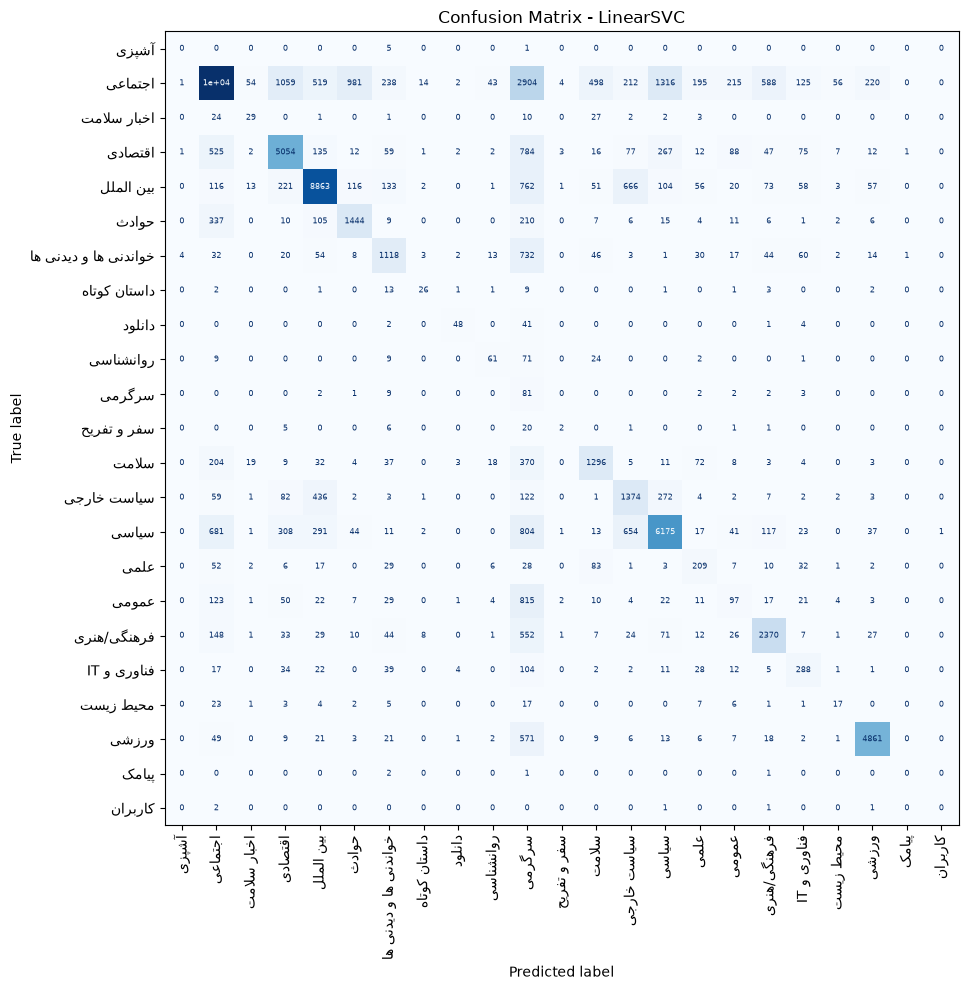

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False
)

# Reducing the font size of values inside cells
for text in disp.text_.ravel():
    text.set_fontsize(6)

ax.set_title("Confusion Matrix - LinearSVC")
plt.tight_layout()
plt.show()


**Top Two Categories with the Highest Misclassification:**   
The model's highest misclassification occurs between the "Social" and "Entertainment" topics, with 2,904 error instances (predicting "Social" instead of "Entertainment").

*(Following that, mutual confusions between "Foreign Policy" with "International" and "Politics" rank next with over 1,300 errors).*

1. **High Lexical Overlap:** Significant overlap of vocabulary in lifestyle news, daily events, and celebrity/marginal topics, which blurs the conceptual boundary between the "Social" and "Entertainment" classes.

2. **Dominant Class Volume & Vector Inseparability:** The large sample size of the "Social" class combined with insufficient vector differentiation in the TF-IDF representation prevents shared keywords from carrying enough discriminative weight for linear separation in `LinearSVC`.
